Car Prediction Challenge -> Kaggle https://www.kaggle.com/datasets/deepcontractor/car-price-prediction-challenge

Linear Regression & Random Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\USER\Documents\TS Academy - Data Science\car prediction challenge\Data\car_price_prediction.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

Notice Levy, Mileage and Engine volume that should be float or int appear as Objects, we will fix that after we check how they appear when we display them, and other features that shouldn't be object but are

In [3]:
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


From the view above we can see some Levy inputs have '-', which after we convert to Integer, will become NaN and we will fix that too and fill up the inputs.
For the Mileage, we can see inputs have (km), we will removes those too and convert to integer.
Next we will check for Engine volume and why it was converted to Object, but lets check the missing values in every other column first

In [4]:
df.isna().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

It says no missing values in our dataset, but we know that we will see some when we start cleaning our data

In [5]:
df.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


 We can see extremely high values in our Price column and really low values, removing them will help our model predict prices better and we will remove the outliers later but for now lets first convert our Mileage from an Object into integers by removing the 'km'

## Data Cleaning

In [6]:
# lets remove the km and convert to int
df['Mileage'] = df['Mileage'].str.replace(' km', '')
df['Mileage'] = df['Mileage'].astype(int)

In [7]:
df['Engine volume'].sample(10)

10042    2.5
10590    1.8
17507    1.5
18021    1.5
9923     1.8
5166     1.5
1503     1.5
18657    2.5
10835    4.6
7391     2.5
Name: Engine volume, dtype: object

We can see some outputs have 'Turbo' attached to them, we can either remove the 'Turbo' and convert to Float or engineer a new feature and pass the 'Turbo' to that new column

In [8]:
df['Turbo'] = df['Engine volume'].astype(str).str.contains('Turbo')

In [9]:
df['Turbo'].sample(10)

3340     False
15321    False
4421      True
16226    False
15809    False
2802     False
8882     False
9637     False
12518    False
18705    False
Name: Turbo, dtype: bool

In [10]:
# converting the values of Turbo from True/False to binary 1/0
df['Turbo'] = df['Turbo'].astype(int)

In [11]:
# df['Turbo'].sample(20)

A new column has been successfully created which show which car engine have turbo engine or not, now we remove the 'Turbo' from the inputs in 'Engine volume'

In [12]:
# lets remove the turbo and convert figures to float
df['Engine volume'] = df['Engine volume'].astype(str).str.replace('Turbo','', regex=False).str.strip()
df['Engine volume'] = df['Engine volume'].astype(float)

In [13]:
df['Engine volume'].dtype

dtype('float64')

In [14]:
# lets convert Levy from object to int
df['Levy'] = pd.to_numeric(df['Levy'], errors='coerce')

We've converted the Levy from object to int, now let's check for missing values before filling them up

In [15]:
# check the percentage of missing values
df['Levy'].isna().mean() * 100

30.24899932421895

We have about 30% missing values, we could either drop the missing rows or fill them up, for this task i will be filling them up 

In [16]:
df['Levy'] = df['Levy'].fillna(df['Levy'].median())

In [17]:
df['Levy'].isna().mean() * 100

0.0

Now for the outliers we noticed in the price column before lets confirm one more time before proceeding to remove the outliers

In [18]:
# checking for outliers in our dataset
df['Price'].describe()

count    1.923700e+04
mean     1.855593e+04
std      1.905813e+05
min      1.000000e+00
25%      5.331000e+03
50%      1.317200e+04
75%      2.207500e+04
max      2.630750e+07
Name: Price, dtype: float64

The dataset contains an extreme high price of 26,307,500, whereas the majority of vehicles are priced between 5,000 ~ 22,000, indicating that the outlier could distort visualizations and statistical summaries, and while we are removing the high ones we will be removing the low ones too, because we have cars priced as low as $1.

During our Exploratory Data Analysis we will also spot outliers in other columns that will affect our models prediction

In [19]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 -Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[~df['Price'].between(lower, upper)]

In [20]:
# How many rows will be removed from our dataset
outliers.shape

(1073, 19)

In [21]:
# Percentage of outliers to be removed
len_df_main = int(len(df))
len_outliers = int(len(outliers))

print(f"Length of the main dataframe -> {len_df_main}\nLength of the outliers -> {len_outliers}")

Length of the main dataframe -> 19237
Length of the outliers -> 1073


In [22]:
percentage_outliers = (len_outliers/len_df_main) * 100
print(f"The percentage of outliers -> {percentage_outliers}")

The percentage of outliers -> 5.577792795134377


We have almost 6% outliers to be removed, a safe number to drop without hurting our dataset

In [23]:
df_main = df[df['Price'].between(lower, upper)].copy()

In [24]:
df_main.shape

(18164, 19)

## Exploratory Data Analysis

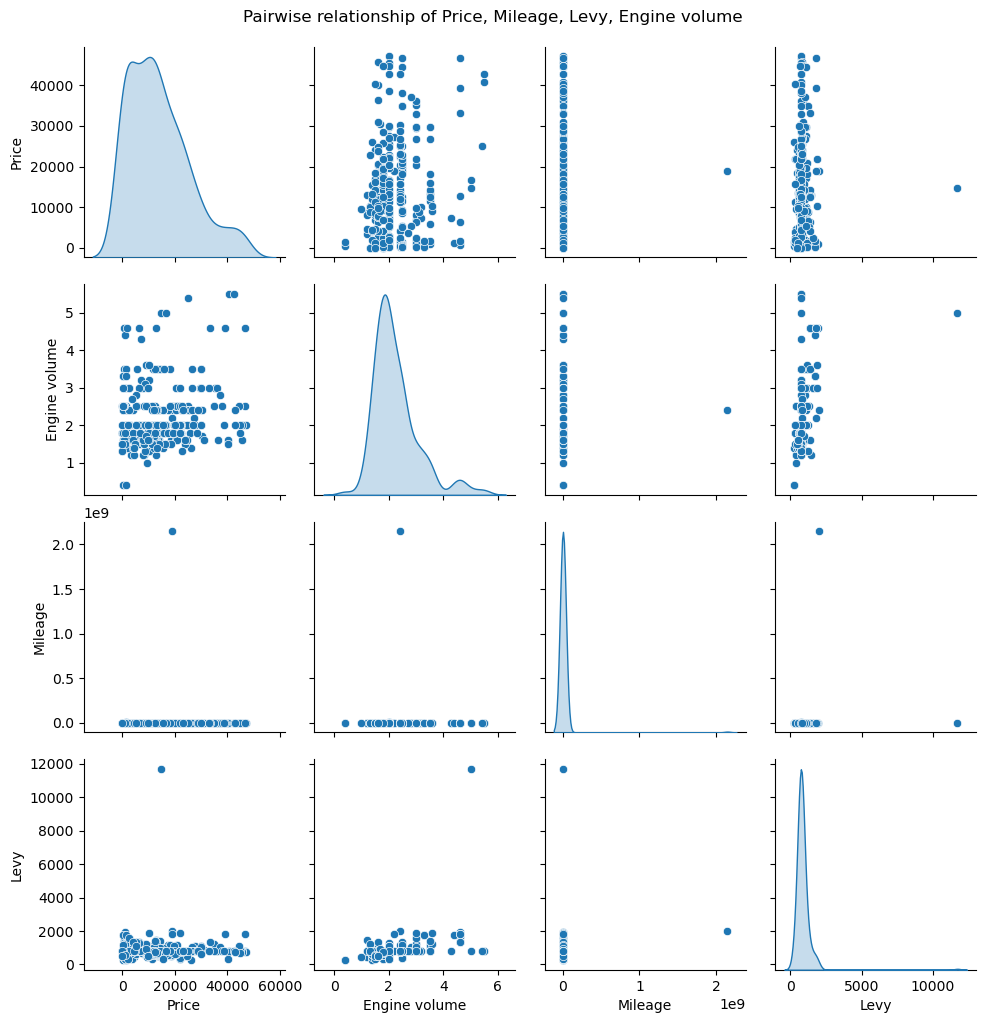

In [25]:
# plotting to see relationship between Price, Mileage, Levy, Engine volume
pair_data = df_main[['Price', 'Engine volume', 'Mileage', 'Levy']].sample(300, random_state=42)
ax = sns.pairplot(pair_data, diag_kind='kde')
ax.fig.suptitle('Pairwise relationship of Price, Mileage, Levy, Engine volume', y=1.02)
plt.show()

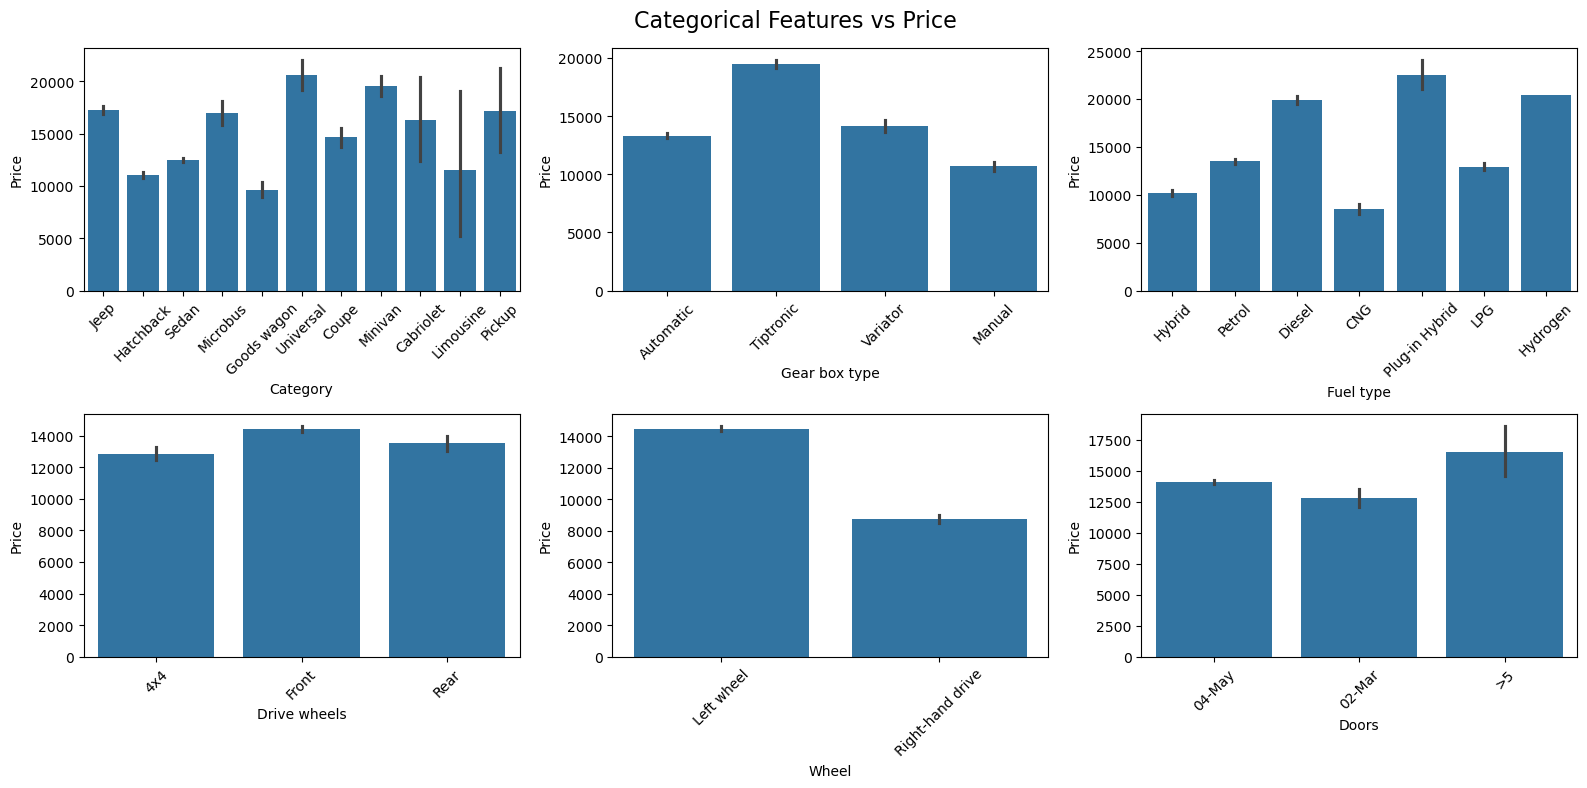

In [26]:
# Relationship between categorical Features and price
fig, axes = plt.subplots(2, 3, figsize=(16,8))

sns.barplot(data=df_main, x='Category', y='Price', ax=axes[0,0])
sns.barplot(data=df_main, x='Gear box type', y='Price', ax=axes[0,1])
sns.barplot(data=df_main, x='Fuel type', y='Price', ax=axes[0,2])
sns.barplot(data=df_main, x='Drive wheels', y='Price', ax=axes[1,0])
sns.barplot(data=df_main, x='Wheel', y='Price', ax=axes[1,1])
sns.barplot(data=df_main, x='Doors', y='Price', ax=axes[1,2])

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Features vs Price', fontsize=16)
plt.tight_layout()
plt.show()

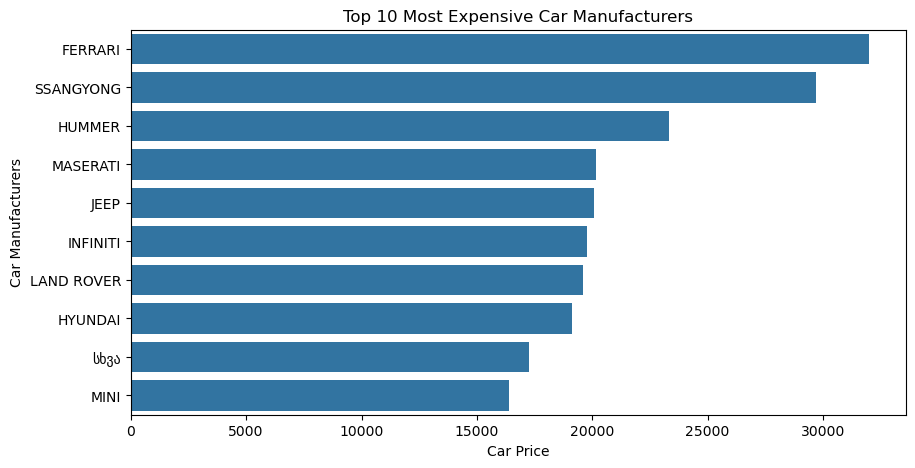

In [27]:
# the 10 most expensive car brand
top_10_cars =  df_main.groupby('Manufacturer')['Price'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10,5))
ax = sns.barplot(data=top_10_cars, y='Manufacturer', x='Price')
ax.set(
    title='Top 10 Most Expensive Car Manufacturers',
    ylabel='Car Manufacturers',
    xlabel='Car Price'
)
plt.show()

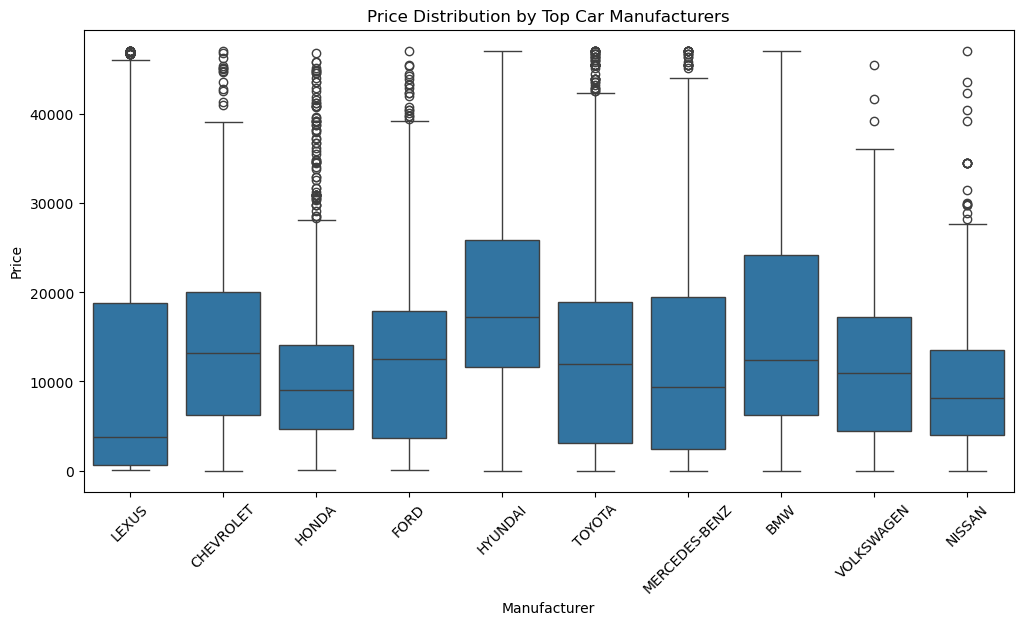

In [28]:
# Most sort after car brands
top_brands = df_main['Manufacturer'].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.boxplot(data=df_main[df_main['Manufacturer'].isin(top_brands)],
            x='Manufacturer',
            y='Price')

plt.title('Price Distribution by Top Car Manufacturers')
plt.xlabel('Manufacturer')
plt.ylabel('Price')
plt.xticks(rotation=45)

plt.show()

In [29]:
# checking car age
max_year = df_main['Prod. year'].max()
df_main['Car age'] = max_year - df_main['Prod. year']
df_main.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Turbo,Car age
0,45654403,13328,1399.0,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,6.0,Automatic,4x4,04-May,Left wheel,Silver,12,0,10
1,44731507,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,192000,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8,0,9
2,45774419,8467,781.0,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000,4.0,Variator,Front,04-May,Right-hand drive,Black,2,0,14
3,45769185,3607,862.0,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,4.0,Automatic,4x4,04-May,Left wheel,White,0,0,9
4,45809263,11726,446.0,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,4.0,Automatic,Front,04-May,Left wheel,Silver,4,0,6


The above is to get the age of each car in our dataset, then we get the mileage per car, we used the replace(0,1) to protect from using 0 to divide to avoid issues that will arise later from that

In [30]:
# Mileage per year
df_main['Mileage per year'] = df_main['Mileage'] / df_main['Car age'].replace(0,1)
df_main.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,...,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Turbo,Car age,Mileage per year
0,45654403,13328,1399.0,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,...,6.0,Automatic,4x4,04-May,Left wheel,Silver,12,0,10,18600.500000
1,44731507,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,...,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8,0,9,21333.333333
2,45774419,8467,781.0,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,...,4.0,Variator,Front,04-May,Right-hand drive,Black,2,0,14,14285.714286
3,45769185,3607,862.0,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,...,4.0,Automatic,4x4,04-May,Left wheel,White,0,0,9,18774.000000
4,45809263,11726,446.0,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,...,4.0,Automatic,Front,04-May,Left wheel,Silver,4,0,6,15316.833333


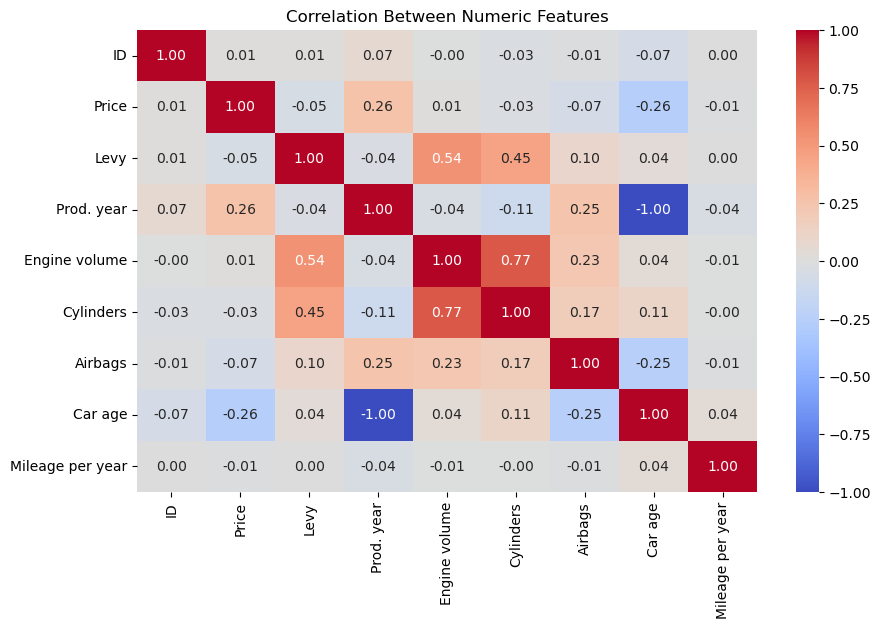

In [31]:
numeric_cols = df_main.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Between Numeric Features')
plt.show()

The correlation heatmap shows weak linear relationships between numerical features and price, indicating that car price is influenced by more complex and categorical factors.

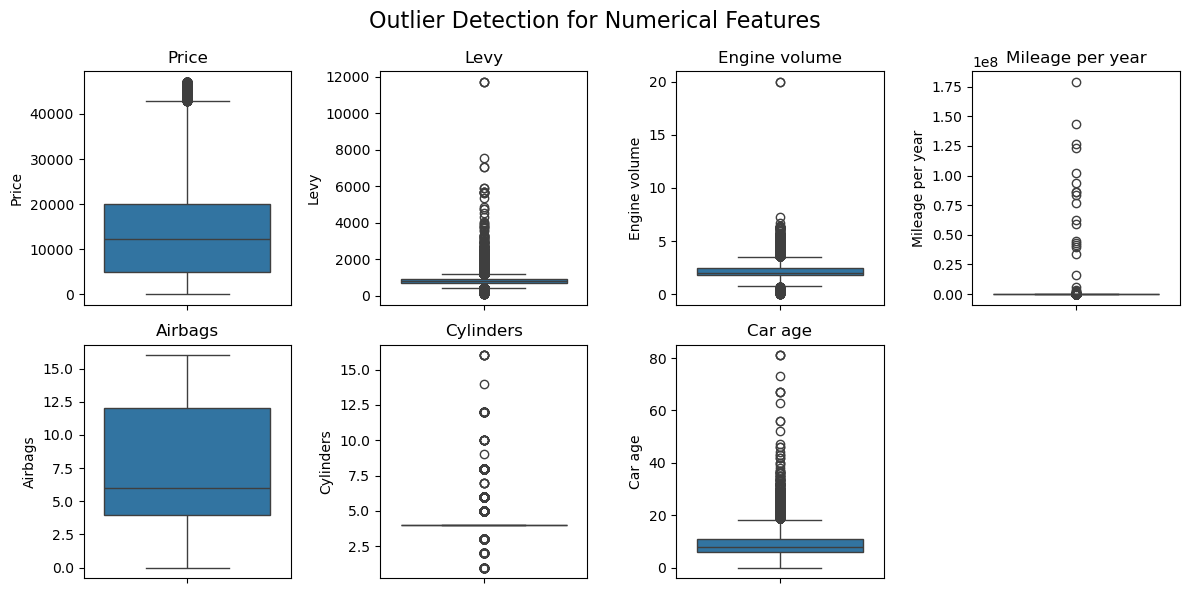

In [32]:
cols = ['Price', 'Levy', 'Engine volume', 'Mileage per year', 'Airbags', 'Cylinders', 'Car age']

plt.figure(figsize=(12,6))
plt.suptitle('Outlier Detection for Numerical Features', fontsize=16)

for i, col in enumerate(cols, 1):
    plt.subplot(2,4,i)
    sns.boxplot(data=df_main, y=col)
    plt.title(col)

plt.tight_layout()
plt.show()
  

In [33]:
df_main[['Price', 'Levy', 'Engine volume', 'Mileage per year', 'Airbags', 'Cylinders', 'Car age']].describe()

,Price,Levy,Engine volume,Mileage per year,Airbags,Cylinders,Car age
count,18164.000000,18164.000000,18164.000000,1.816400e+04,18164.000000,18164.000000,18164.000000
mean,14024.917860,859.623541,2.279151,9.948172e+04,6.585664,4.548503,9.344638
std,11377.779677,390.332597,0.857795,2.838863e+06,4.323290,1.158246,5.624060
min,1.000000,87.000000,0.000000,0.000000e+00,0.000000,1.000000,0.000000
25%,4861.000000,707.000000,1.800000,1.000000e+04,4.000000,4.000000,6.000000
50%,12231.000000,781.000000,2.000000,1.562500e+04,6.000000,4.000000,8.000000
75%,20071.000000,891.000000,2.500000,2.281767e+04,12.000000,4.000000,11.000000
max,47120.000000,11714.000000,20.000000,1.789570e+08,16.000000,16.000000,81.000000


From this final check to check for outliers, we can spot some clear issues from dataset that will eventually affect our model training, like:
Levy -> 75% = 891, Max = 11714, this is 13x larger than the 75th percentile, not impossible but might affect the model prediction and we will this one.
Mean -> Mean = 2.27, Median = 2.0, Max = 20, and no car has a 20L Engine volume
Mileage per year -> Mean = 99k, Median = 15k, Max = 178 million which is impossible
Car age -> Mean = 9, Median = 8, Max = 81 years old car, possible  but rare, might be a classic car or a wrong date entry

Next course of action is removing the impossible figures from the dataset from Car age, Mileage per year, Engine volume

In [34]:
len(df_main)

18164

In [35]:
# We will cap the age of cars at 40
df_main = df_main[df_main['Car age'] <= 40]
len(df_main)

18145

No car has more than 8L Engine Volume

In [36]:
df_main = df_main[df_main['Engine volume'] <= 8]
len(df_main)

18143

In [37]:
# We are capping the mileage per year to 200k
df_main = df_main[df_main['Mileage per year'] <= 200000]
len(df_main)

18098

## Feature Engineering

In [38]:
cols = ['Category', 'Leather interior', 'Fuel type', 'Gear box type']

for col in cols:
    print(col, df_main[col].unique())

Category ['Jeep' 'Hatchback' 'Sedan' 'Microbus' 'Goods wagon' 'Universal' 'Coupe'
 'Minivan' 'Cabriolet' 'Pickup' 'Limousine']
Leather interior ['Yes' 'No']
Fuel type ['Hybrid' 'Petrol' 'Diesel' 'CNG' 'Plug-in Hybrid' 'LPG' 'Hydrogen']
Gear box type ['Automatic' 'Tiptronic' 'Variator' 'Manual']


Feature Engineering 

In [39]:
df_main['Leather interior'] = df_main['Leather interior'].map({
    'Yes':1,
    'No':0
})
# df_main.info()

In [40]:
df_main['Gear box type'] = df_main['Gear box type'].replace({
    'Tiptronic':'Automatic',
    'Variator':'Automatic'
})

We changed 'Tiptronic' and 'Variator' to 'Automatic' because they are just another type of Automatic, we now we have Automatic and Manual 'Gear box type'

In [41]:
df_main['Gear box type'].unique()

array(['Automatic', 'Manual'], dtype=object)

In [42]:
df_main['Gear box type'] = df_main['Gear box type'].map({
    'Automatic':1,
    'Manual':0
})
# df_main.info()

In [43]:
df_main['Fuel type'] = df_main['Fuel type'].replace({
    'Plug-in Hybrid': 'Hybrid',
    'CNG':'Gas',
    'LPG':'Gas',
    'Hydrogen':'Gas'
})

From what we did with the Automatic we can understand what we just did here

In [44]:
df_main['Fuel type'].unique()

array(['Hybrid', 'Petrol', 'Diesel', 'Gas'], dtype=object)

In [45]:
df_main = pd.get_dummies(
    df_main,
    columns=['Fuel type'],
    drop_first=True
)
# df_main.info()

In [46]:
cols = ['Fuel type_Gas', 'Fuel type_Hybrid', 'Fuel type_Petrol']

for col in cols:
    print(col, df_main[col].unique())

df_main[cols] = df_main[cols].astype(int)
# df_main.info()

Fuel type_Gas [False  True]
Fuel type_Hybrid [ True False]
Fuel type_Petrol [False  True]


In [47]:
cols = ['Levy', 'Car age', 'Mileage per year', 'Engine volume', 'Cylinders', 
             'Leather interior', 'Gear box type', 'Airbags', 
             'Fuel type_Gas', 'Fuel type_Hybrid', 'Fuel type_Petrol', 'Turbo']
display(df_main[cols].isna().sum())
# df_main = df_main.dropna(subset=cols)

Levy                0
Car age             0
Mileage per year    0
Engine volume       0
Cylinders           0
Leather interior    0
Gear box type       0
Airbags             0
Fuel type_Gas       0
Fuel type_Hybrid    0
Fuel type_Petrol    0
Turbo               0
dtype: int64

In [76]:
df_main = pd.get_dummies(df_main, columns=['Manufacturer','Category','Drive wheels'], drop_first=True)
# df_main.info()

## Data splitting and Model Training

In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [90]:
# features to be used 
base_cols = ['Levy', 'Car age', 'Mileage per year', 'Engine volume', 'Cylinders',
             'Leather interior', 'Gear box type', 'Airbags',
             'Fuel type_Gas', 'Fuel type_Hybrid', 'Fuel type_Petrol', 'Turbo']

encoded_cols = [col for col in df_main.columns if col.startswith('Manufacturer_') 
                or col.startswith('Category_') 
                or col.startswith('Drive wheels_')]

x = df_main[base_cols + encoded_cols]
y = df_main['Price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

In [51]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# x_train = scaler.fit_transform(x_train)
# x_test = scaler.transform(x_test)

In [91]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [92]:
Coefficients = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': model.coef_
})

intercept = model.intercept_

display(Coefficients)
print(f"Intercept -> {intercept}")

,Feature,Coefficient
0,Levy,-2.675044
1,Car age,-754.962944
2,Mileage per year,-0.097203
3,Engine volume,1902.513307
4,Cylinders,72.071599
...,...,...
77,Category_Pickup,-3200.153545
78,Category_Sedan,-7513.778005
79,Category_Universal,534.767689
80,Drive wheels_Front,2098.878015


Intercept -> 22779.91776681371


In [93]:
y_pred = model.predict(x_train)
# print(y_pred[:10])

In [94]:
res_pred = pd.DataFrame({
    'Actual':y_train,
    'Predicted': y_pred
})

display(res_pred.head())

,Actual,Predicted
4591,18817,14210.561684
12318,23505,25810.396550
10123,941,14168.071540
18132,627,13795.239711
14590,14426,12358.579929


In [95]:
y_pred_test = model.predict(x_test)
# print(y_pred_test[:10])

In [96]:
res_pred_test = pd.DataFrame({
    'Actual':y_test,
    'Predicted': y_pred_test
})

display(res_pred.head())

,Actual,Predicted
4591,18817,14210.561684
12318,23505,25810.396550
10123,941,14168.071540
18132,627,13795.239711
14590,14426,12358.579929


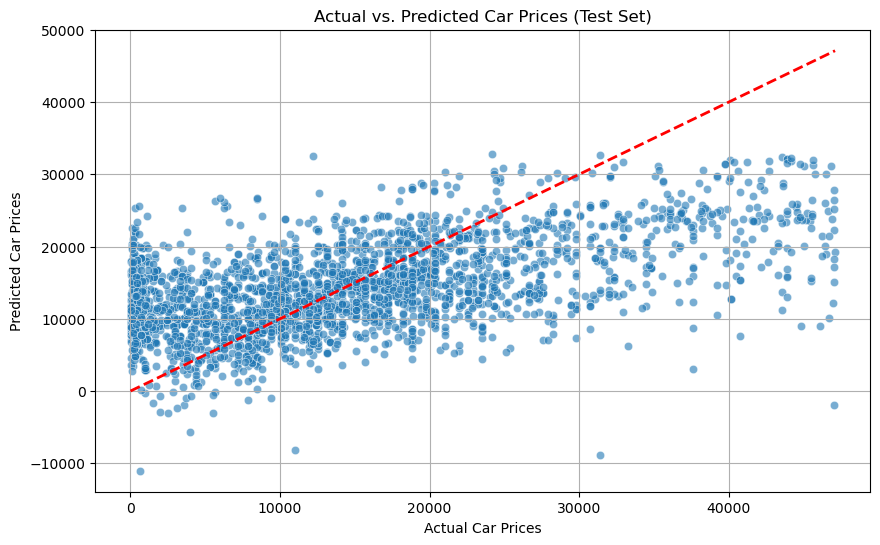

In [97]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Car Prices')
plt.ylabel('Predicted Car Prices')
plt.title('Actual vs. Predicted Car Prices (Test Set)')
plt.grid(True)
plt.show()

In [98]:
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate metrics
MAE = mean_absolute_error(y_test, y_pred_test)

# Round the results
MAE = round(MAE, 2)

# Print results
print(MAE)


# average_house_price = df_main['Price'].mean()
# MAE_percentage_of_avg = (MAE / average_house_price) * 100

# print(round(MAE_percentage_of_avg, 2))


# Calculate R-squared for the training set
r2_train = r2_score(y_train, y_pred)

# Calculate R-squared for the test set
r2_test = r2_score(y_test, y_pred_test)

print(round(r2_train, 2))
print(round(r2_test, 2))

7435.57
0.3
0.32


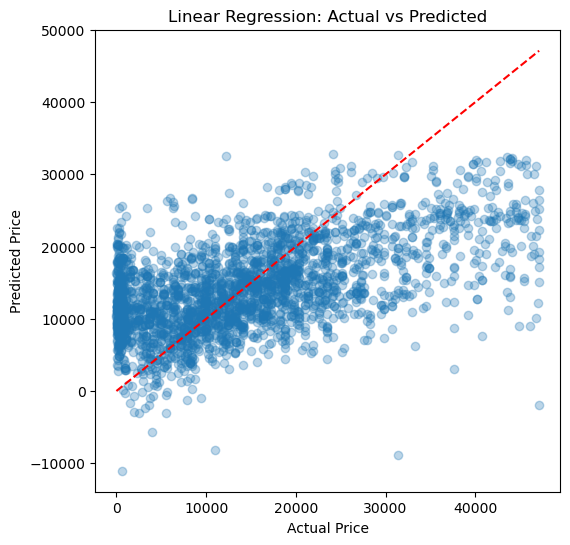

In [99]:
# Predicted vs Actual plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

Lets try Decision Tree

In [87]:
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree

In [178]:
model_dt = DecisionTreeRegressor(
    max_depth=15,
    min_samples_split=8,
    min_samples_leaf=4,
    random_state=100
)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=100)
model_dt.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=15, min_samples_leaf=4, min_samples_split=8,
                      random_state=100)

In [179]:
y_pred_dt = model_dt.predict(x_train)

res_dt = pd.DataFrame({
    'Actual':y_train,
    'DT_Predict': y_pred_dt
})

display(res_dt.head())

,Actual,DT_Predict
2727,16308,20698.50
11507,30,2053.25
18491,31675,23625.50
18342,10036,9901.00
3851,80,1370.00


In [180]:
y_pred_dt_test = model_dt.predict(x_test)

res_dt_test = pd.DataFrame({
    'Actual':y_test,
    'DT_Predict': y_pred_dt_test
})

display(res_dt_test.head())

,Actual,DT_Predict
10533,21953,22266.400000
11150,46101,41082.166667
8888,4547,4285.666667
9141,10976,10373.478261
1564,14113,10987.857143


In [181]:
train_r2 = r2_score(y_train, y_pred_dt)
test_r2 = r2_score(y_test, y_pred_dt_test)

train_mae = mean_absolute_error(y_train, y_pred_dt)
test_mae = mean_absolute_error(y_test, y_pred_dt_test)

print("Training R² Score:", round(train_r2, 4))
print("Test R² Score:", round(test_r2, 4))

print("Training MAE:", round(train_mae, 2))
print("Test MAE:", round(test_mae, 2))

Training R² Score: 0.8186
Test R² Score: 0.6379
Training MAE: 3031.08
Test MAE: 4383.78


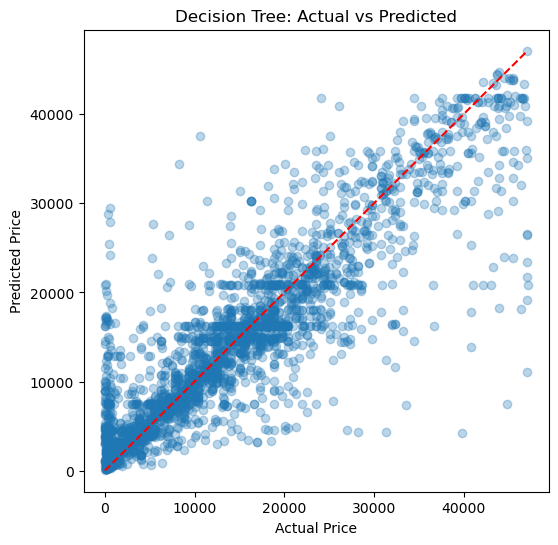

In [103]:
# Predicted vs Actual plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_dt_test, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree: Actual vs Predicted")
plt.show()

In [69]:
from sklearn.ensemble import RandomForestRegressor

In [163]:
rf_regressor = RandomForestRegressor(
    n_estimators=500,
    max_depth=25,
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=100,
    n_jobs=-1
)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=100)
rf_regressor.fit(x_train, y_train)

RandomForestRegressor(max_depth=25, min_samples_leaf=3, min_samples_split=10,
                      n_estimators=500, n_jobs=-1, random_state=100)

In [164]:
# Make predictions for the training dataset
y_pred_train_rf = rf_regressor.predict(x_train)

# Make predictions for the test dataset
y_pred_test_rf = rf_regressor.predict(x_test)

# Display some predictions
print("Random Forest Predictions (Training Set - first 10):")
print(y_pred_train_rf[:10])
print("\nRandom Forest Predictions (Test Set - first 10):")
print(y_pred_test_rf[:10])

Random Forest Predictions (Training Set - first 10):
[18136.20589709  3731.55698075 28398.23873525 10560.13265928
  5027.72434048  1804.77209683 28780.56962134 20311.98782764
  1297.86895445  4873.89290959]

Random Forest Predictions (Test Set - first 10):
[24085.97287322 38192.09796587  4648.20957258 10553.5111044
  9967.81426588 17820.52104615 19791.10873268 18503.50707228
  2794.25813755  1815.35770207]


In [165]:
# Evaluate Random Forest model
rf_train_r2 = r2_score(y_train, y_pred_train_rf)
rf_test_r2 = r2_score(y_test, y_pred_test_rf)

rf_train_mae = mean_absolute_error(y_train, y_pred_train_rf)
rf_test_mae = mean_absolute_error(y_test, y_pred_test_rf)

print("Training R² Score:", round(rf_train_r2, 4))
print("Test R² Score:", round(rf_test_r2, 4))

print("Training MAE:", round(rf_train_mae, 2))
print("Test MAE:", round(rf_test_mae, 2))

Training R² Score: 0.8615
Test R² Score: 0.73
Training MAE: 2609.39
Test MAE: 3721.39


Random Forest achieved the best performance with a Test R² of 0.73 and the lowest prediction error, outperforming both Linear Regression and Decision Tree models.

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted")
plt.show()